<a href="https://colab.research.google.com/github/devikarajeev770-afk/AI-ML-Course/blob/main/Mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Environment Setup and Library Imports

This block imports all necessary data manipulation, statistical modelling, and visualization libraries.

In [1]:
# 1.1 Importing Required Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Enable inline plotting for Jupyter/Colab notebooks
%matplotlib inline

2. Visualization Configuration

The following configuration ensures that all generated plots maintain a consistent, high-quality professional appearance as specified in the sources

In [7]:
# 2.1 Seaborn Theme Configuration
sns.set_theme(context='notebook',
              style='white',
              palette='deep',
              font='DejaVu Sans',
              font_scale=1.5,
              color_codes=True,
              rc=None)

# 2.2 Detailed Matplotlib Resource Parameters (rcParams)
# Figure Settings
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['figure.facecolor'] = '#F0F8FF'
plt.rcParams['figure.titlesize'] = 'medium'
plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.edgecolor'] = 'Blue'
plt.rcParams['figure.frameon'] = True
plt.rcParams["figure.autolayout"] = True

# Axes Settings
plt.rcParams['axes.facecolor'] = '#F5F5DC'
plt.rcParams['axes.titlesize'] = 25
plt.rcParams["axes.titleweight"] = 'normal'
plt.rcParams["axes.titlecolor"] = 'Olive'
plt.rcParams['axes.edgecolor'] = 'pink'
plt.rcParams["axes.linewidth"] = 2
plt.rcParams["axes.grid"] = True
plt.rcParams['axes.titlelocation'] = 'center'
plt.rcParams["axes.labelsize"] = 20
plt.rcParams["axes.labelpad"] = 2
plt.rcParams['axes.labelweight'] = 1
plt.rcParams["axes.labelcolor"] = 'Olive'
plt.rcParams["axes.axisbelow"] = False
plt.rcParams['axes.xmargin'] = .2
plt.rcParams["axes.ymargin"] = .2

# Ticks and Grid Settings
plt.rcParams["xtick.bottom"] = True
plt.rcParams['xtick.color'] = '#A52A2A'
plt.rcParams["ytick.left"] = True
plt.rcParams['ytick.color'] = '#A52A2A'
plt.rcParams['grid.color'] = 'green'
plt.rcParams['grid.linestyle'] = '--'
plt.rcParams['grid.linewidth'] = .5
plt.rcParams['grid.alpha'] = .3

# Legend Settings
plt.rcParams['legend.loc'] = 'best'
plt.rcParams['legend.facecolor'] = 'NavajoWhite'
plt.rcParams['legend.edgecolor'] = 'pink'
plt.rcParams['legend.shadow'] = True
plt.rcParams['legend.fontsize'] = 20

# Font Settings
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 14

2. Data Loading and Preprocessing

This section handles the acquisition of the EEG and audio signal dataset and formats it for subsequent analysis.

In [3]:
# 2.1 Data Acquisition
# Loading the dataset from the specified GitHub repository
url = "https://raw.githubusercontent.com/sijuswamy/A-modern-approach-to-Research/main/X.csv"
df = pd.read_csv(url)

# 2.2 Data Formatting
# Renaming columns for clarity as per the project requirements
# Original columns: time, x1, x2, y
# New columns: Time, Prefrontal Cortex_EEG (x1), Auditory Cortex_EEG (x2), Sound Signal (y)
df.columns = ["Time", "Prefrontal Cortex_EEG", "Auditory Cortex_EEG", "Sound Signal"]

# Displaying the first few rows to verify successful loading and renaming
print("Dataset Preview:")
display(df.head())

# Basic information about the dataset (Checking for 2400 samples as per source 8)
print("\nDataset Info:")
print(df.info())

Dataset Preview:


,Time,Prefrontal Cortex_EEG,Auditory Cortex_EEG,Sound Signal
0,0.05,-0.562320,-2.274491,-2.386526
1,0.10,0.505550,-1.451586,-0.371560
2,0.15,-0.857812,-0.271215,-12.586452
3,0.20,-0.735262,-3.402501,-0.248121
4,0.25,-1.244369,-2.199162,-10.681437



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2400 entries, 0 to 2399
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Time                   2400 non-null   float64
 1   Prefrontal Cortex_EEG  2400 non-null   float64
 2   Auditory Cortex_EEG    2400 non-null   float64
 3   Sound Signal           2400 non-null   float64
dtypes: float64(4)
memory usage: 75.1 KB
None


3. Task 1: Preliminary Data Analysis (EDA)

This sub-section generates line plots to observe how the EEG and audio signals fluctuate over the 2-minute recording period


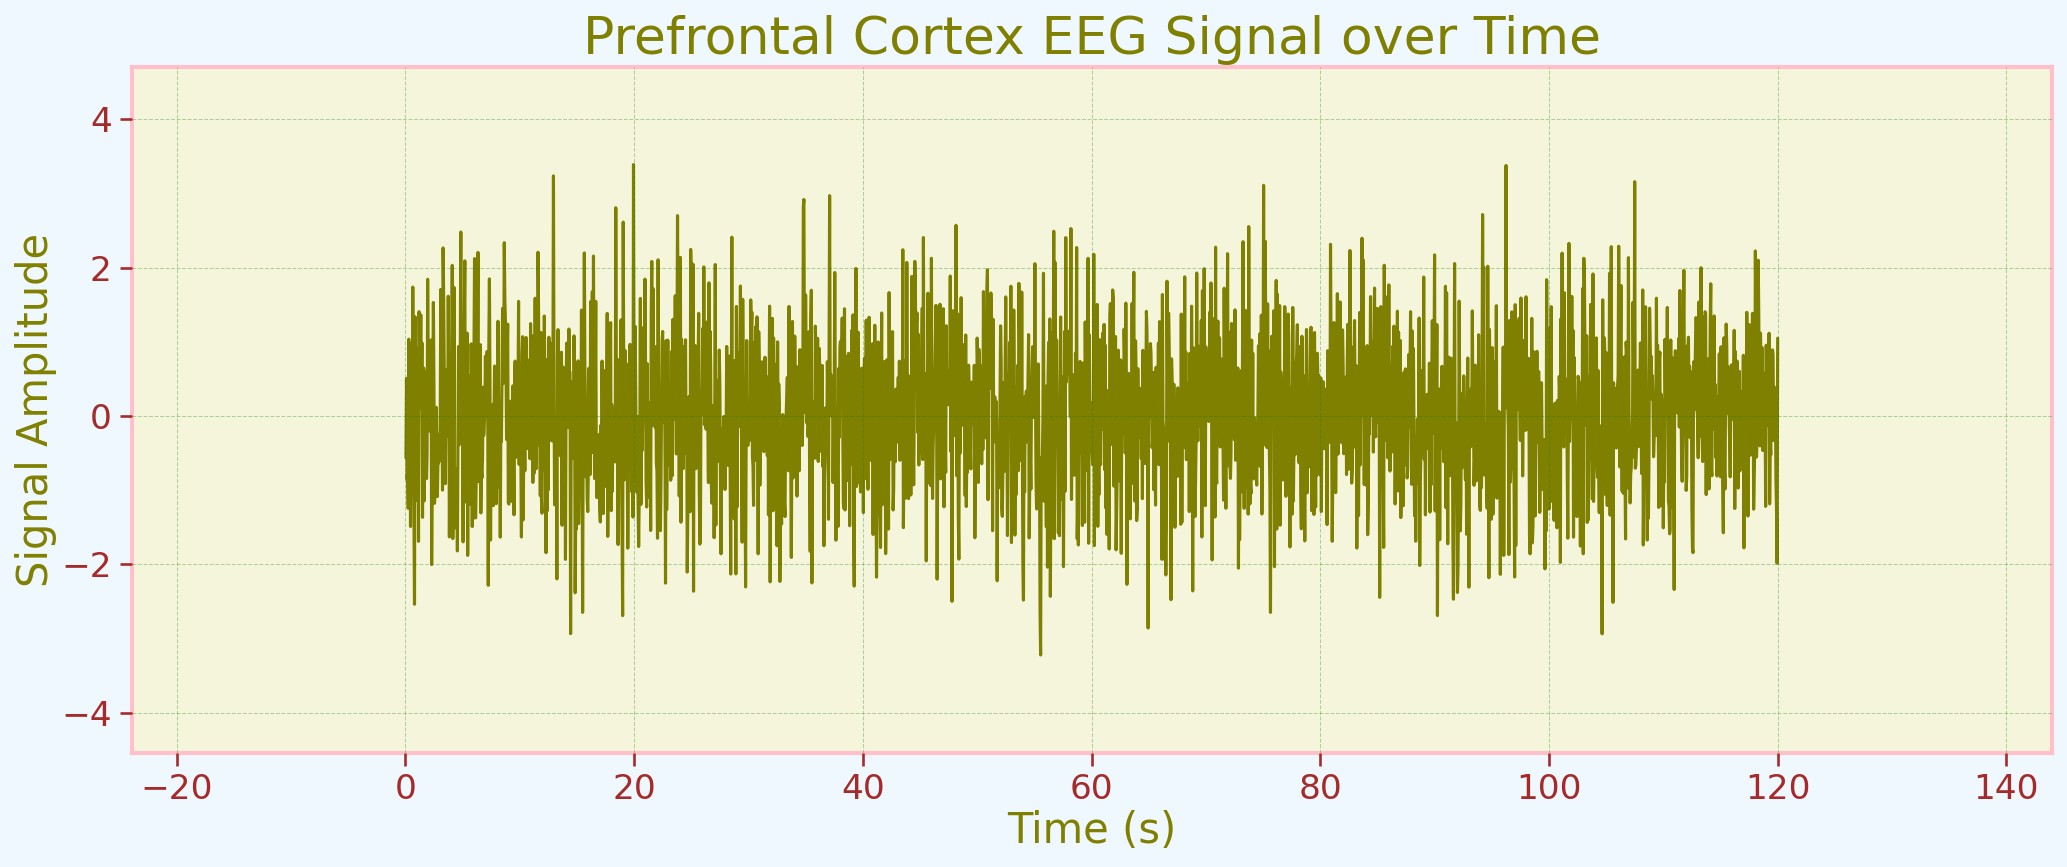

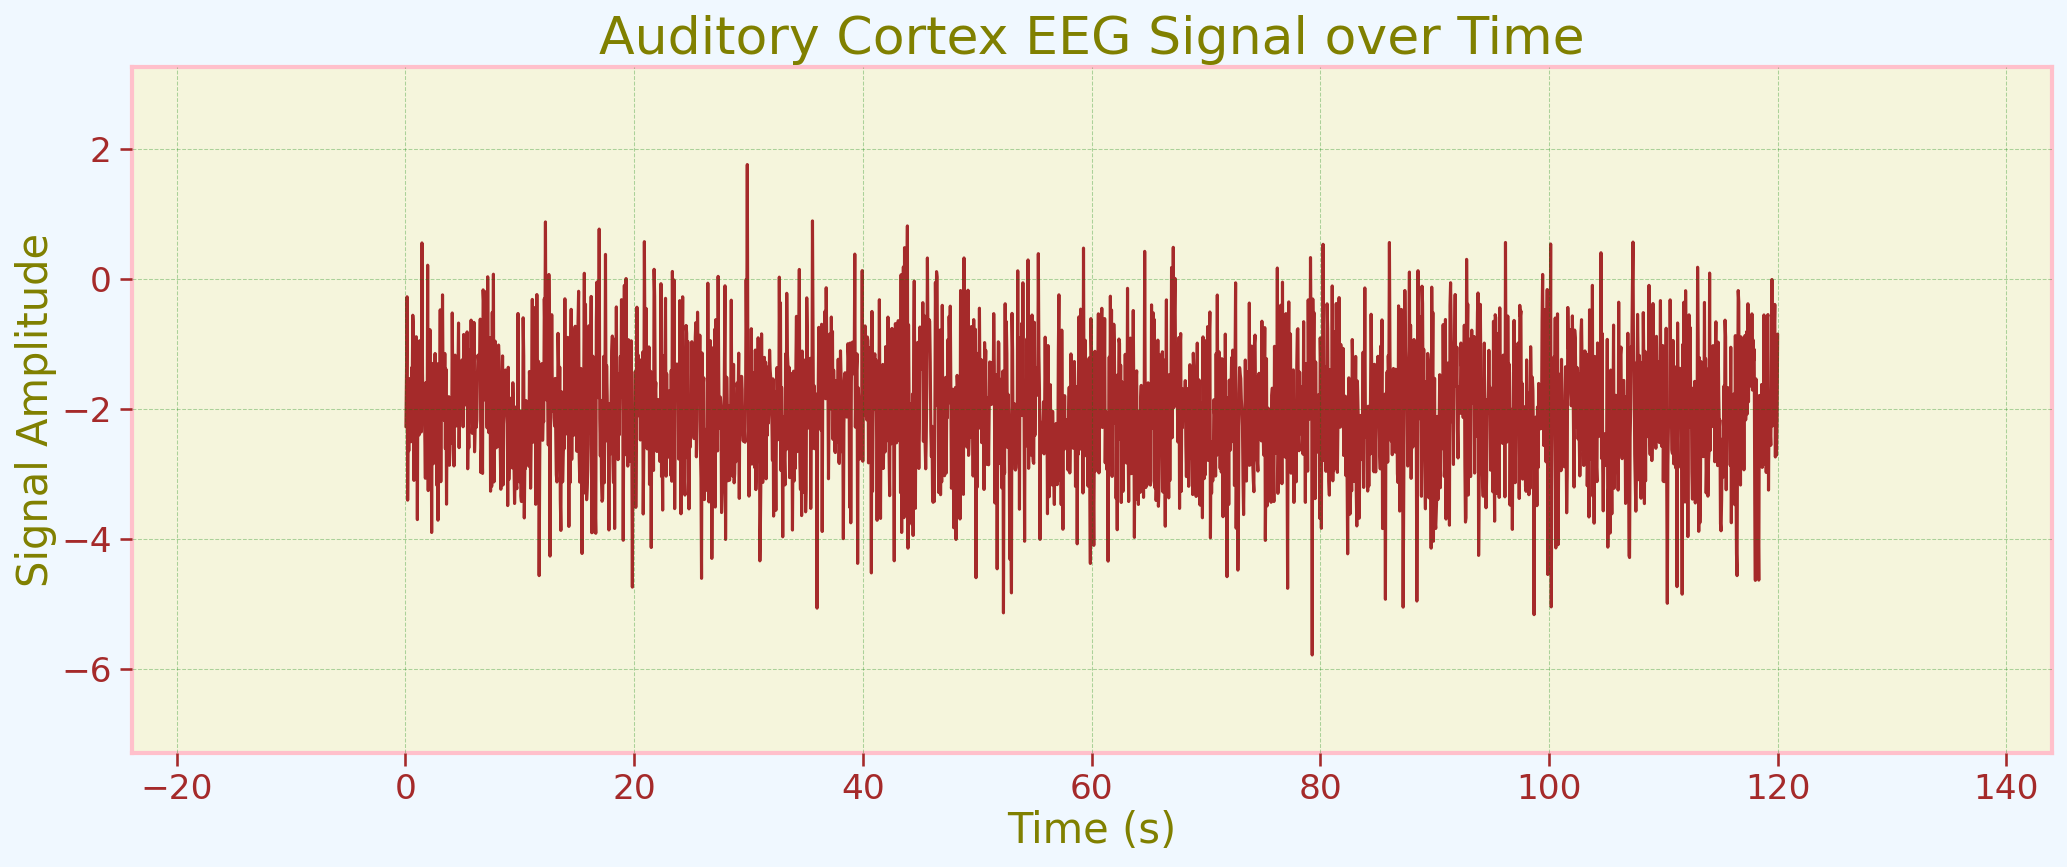

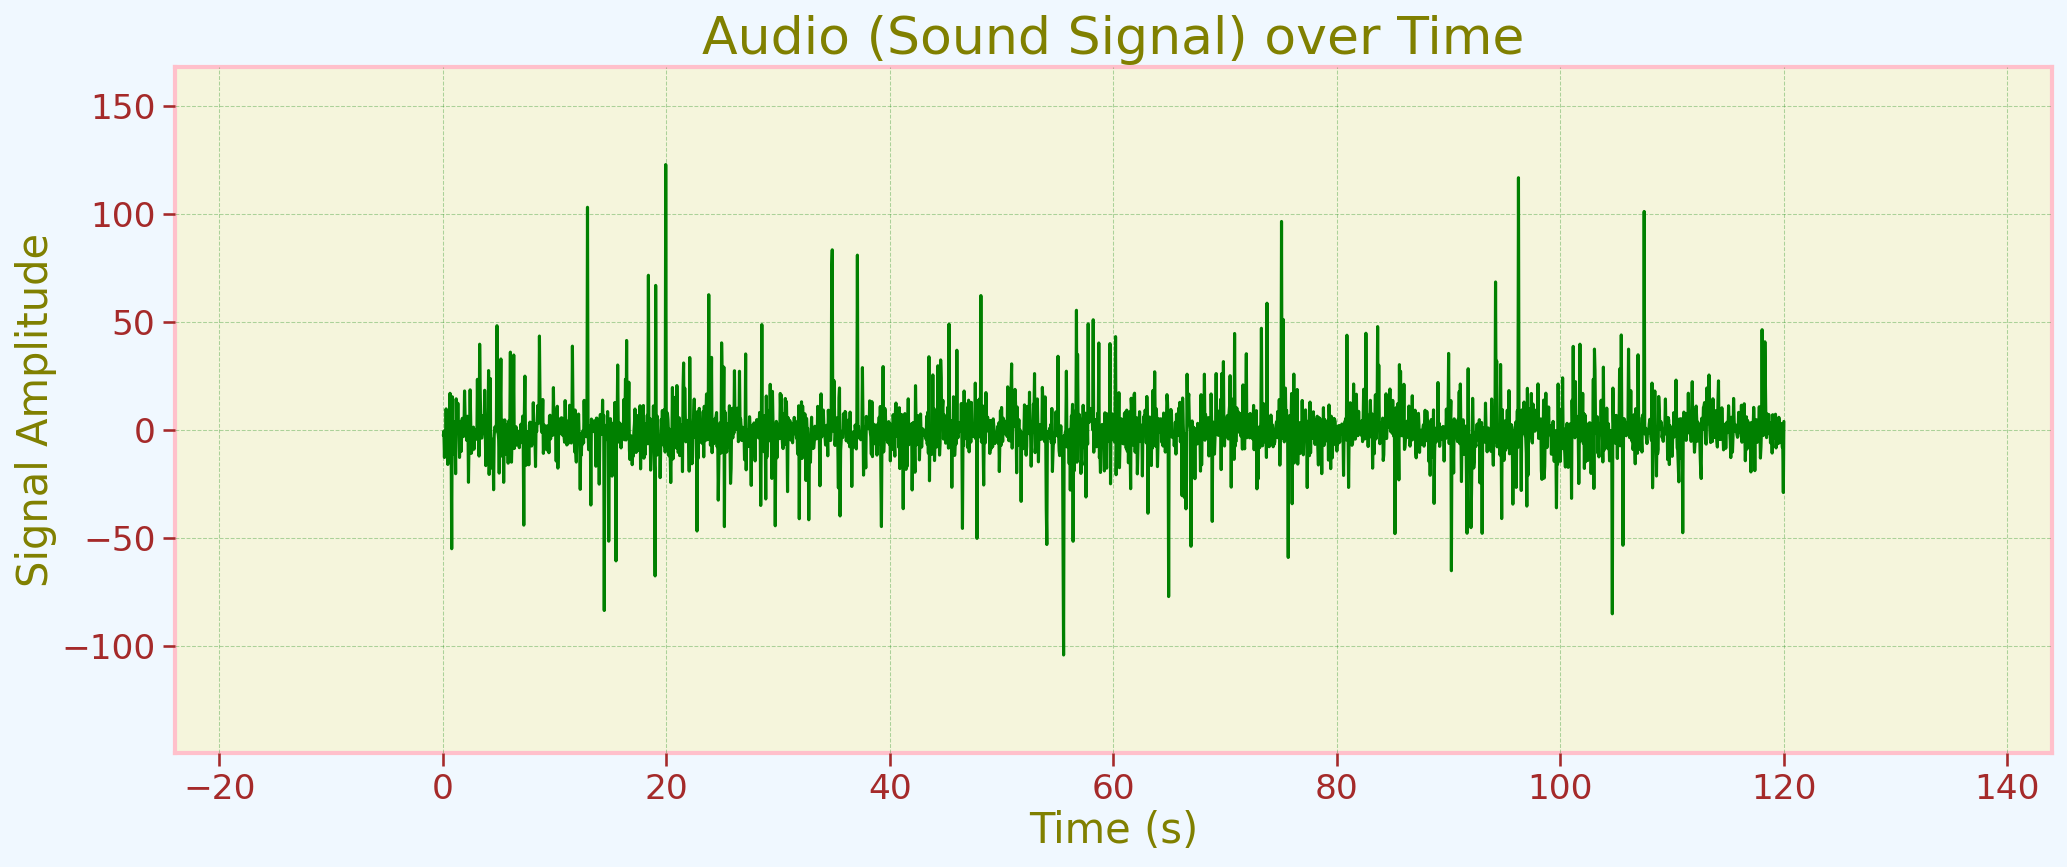

In [8]:
# 3.1 Time Series Analysis
# Plotting the Prefrontal Cortex EEG signal over time
fig1 = plt.figure(figsize=(14, 6))
sns.lineplot(data=df, x="Time", y="Prefrontal Cortex_EEG", color='Olive')
plt.title("Prefrontal Cortex EEG Signal over Time")
plt.xlabel("Time (s)")
plt.ylabel("Signal Amplitude")
plt.show()
fig1.savefig('prefrontal_EEG_timeseries.png')

# Plotting the Auditory Cortex EEG signal over time
fig2 = plt.figure(figsize=(14, 6))
sns.lineplot(data=df, x="Time", y="Auditory Cortex_EEG", color='brown')
plt.title("Auditory Cortex EEG Signal over Time")
plt.xlabel("Time (s)")
plt.ylabel("Signal Amplitude")
plt.show()
fig2.savefig('auditory_EEG_timeseries.png')

# Plotting the Sound Signal (Audio) over time
fig3 = plt.figure(figsize=(14, 6))
sns.lineplot(data=df, x="Time", y="Sound Signal", color='green')
plt.title("Audio (Sound Signal) over Time")
plt.xlabel("Time (s)")
plt.ylabel("Signal Amplitude")
plt.show()
fig3.savefig('sound_signal_timeseries.png')

3.2 Signal Distribution Analysis

We use histograms with Kernel Density Estimate (KDE) plots to examine the statistical distribution of each signal, which is critical for understanding the noise characteristics (e.g., Gaussian noise)

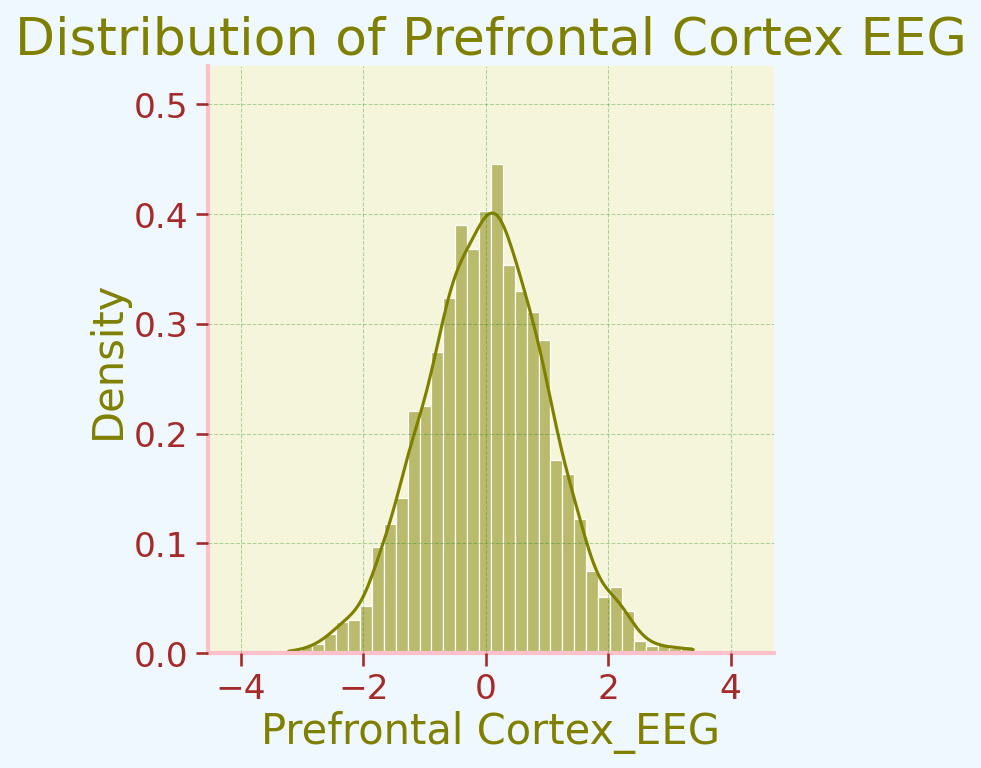

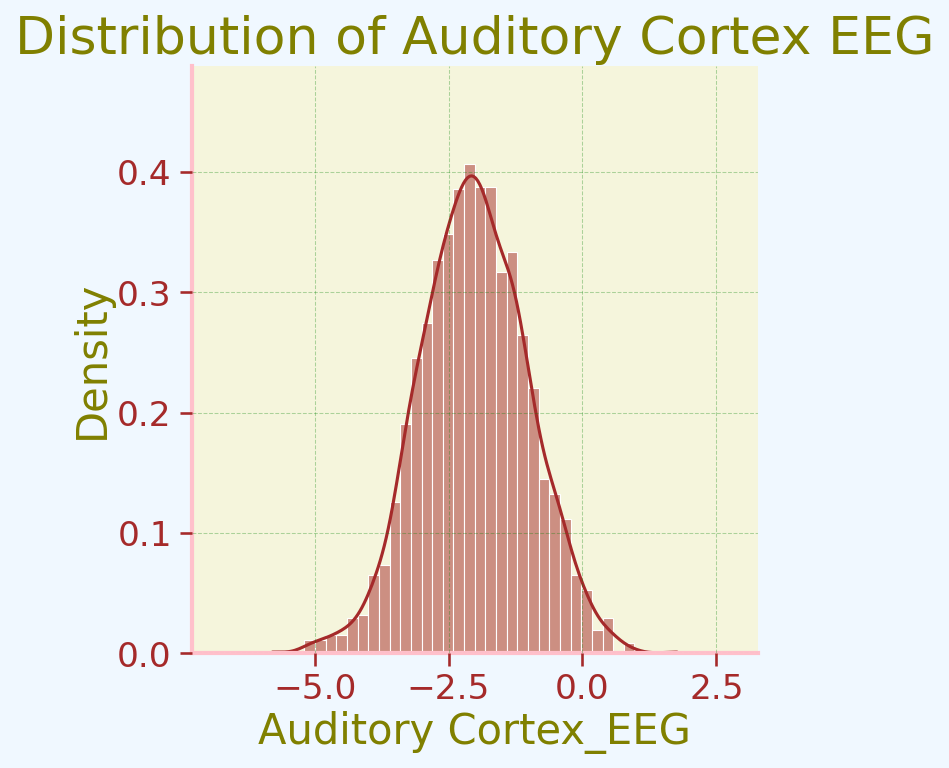

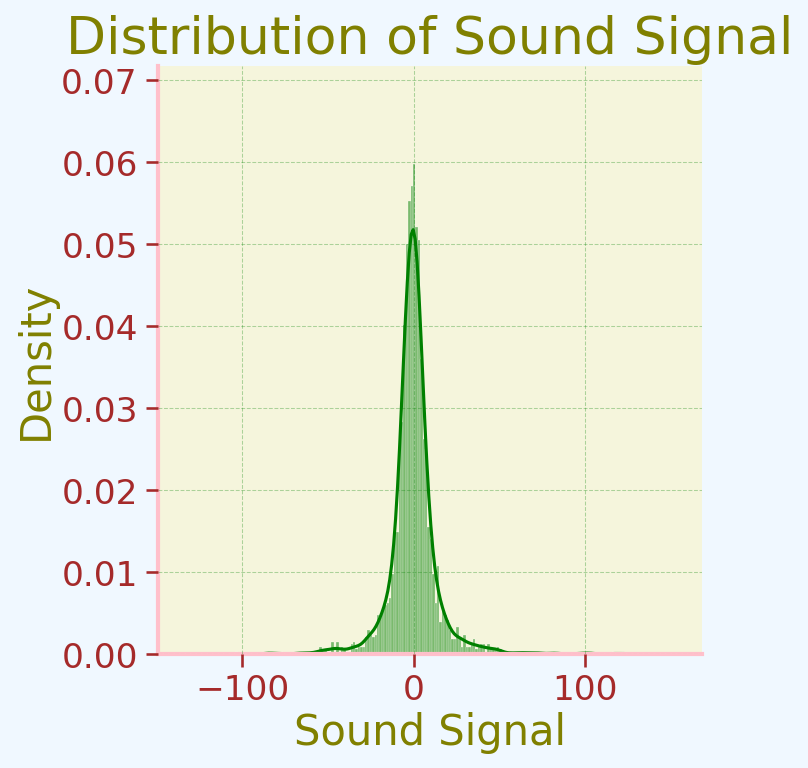

In [9]:
# 3.2 Signal Distribution Analysis
# Distribution of Prefrontal Cortex EEG
fig4 = sns.displot(df["Prefrontal Cortex_EEG"], stat='density', kde=True, color='Olive')
plt.title("Distribution of Prefrontal Cortex EEG")
plt.show()
fig4.savefig("Prefrontal_distribution.png")

# Distribution of Auditory Cortex EEG
fig5 = sns.displot(df["Auditory Cortex_EEG"], stat='density', kde=True, color='brown')
plt.title("Distribution of Auditory Cortex EEG")
plt.show()
fig5.savefig("Auditory_distribution.png")

# Distribution of Sound Signal
fig6 = sns.displot(df["Sound Signal"], stat='density', kde=True, color='green')
plt.title("Distribution of Sound Signal")
plt.show()
fig6.savefig("Sound_distribution.png")

3.3 Correlation and Scatter Analysis

This final EDA step quantifies and visualises the dependencies between the input brain signals (x
1
​
 ,x
2
​
 ) and the output audio signal (y)

Correlation Matrix:


,Prefrontal Cortex_EEG,Auditory Cortex_EEG,Sound Signal
Prefrontal Cortex_EEG,1.000000,-0.024313,0.862507
Auditory Cortex_EEG,-0.024313,1.000000,-0.252638
Sound Signal,0.862507,-0.252638,1.000000


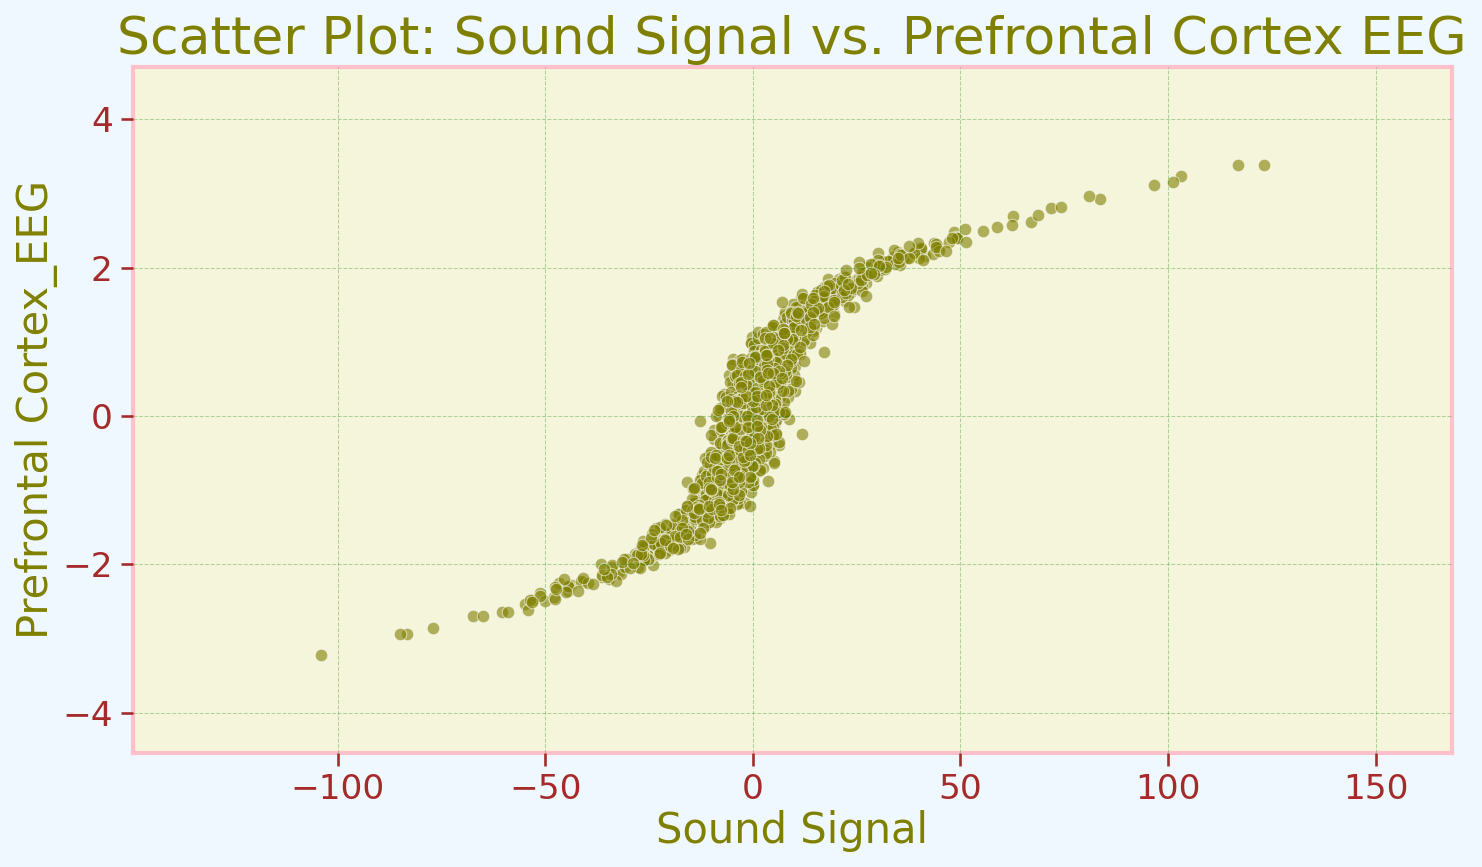

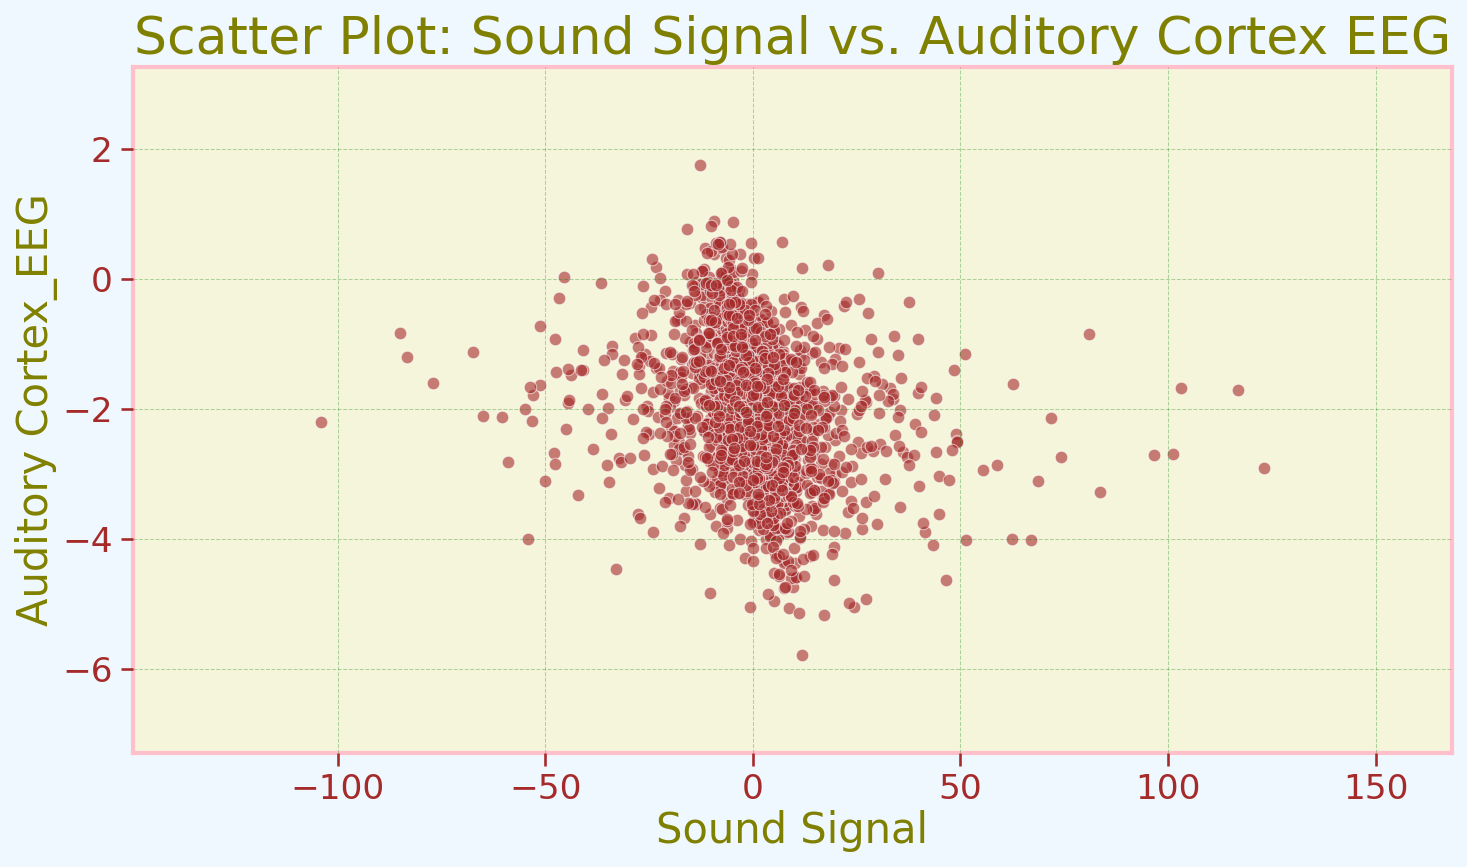

In [10]:
# 3.3 Correlation Analysis
# Calculating the correlation matrix for the signals (excluding Time)
print("Correlation Matrix:")
correlation_matrix = df[["Prefrontal Cortex_EEG", "Auditory Cortex_EEG", "Sound Signal"]].corr()
display(correlation_matrix)

# 3.4 Scatter Analysis
# Scatter plot between Sound Signal and Prefrontal Cortex EEG
fig7 = plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Sound Signal", y="Prefrontal Cortex_EEG", alpha=0.6, color='Olive')
plt.title("Scatter Plot: Sound Signal vs. Prefrontal Cortex EEG")
plt.show()
fig7.savefig("ScatterPlot_Prefrontal.png")

# Scatter plot between Sound Signal and Auditory Cortex EEG
fig8 = plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="Sound Signal", y="Auditory Cortex_EEG", alpha=0.6, color='brown')
plt.title("Scatter Plot: Sound Signal vs. Auditory Cortex EEG")
plt.show()
fig8.savefig("ScatterPlot_Auditory.png")

4. Task 2: Polynomial Regression Modelling

Before starting the individual models, let's extract our variables into simple names to match the research equations

In [12]:
# Extracting variables for ease of use in model construction
x1 = df["Prefrontal Cortex_EEG"]
x2 = df["Auditory Cortex_EEG"]
y = df["Sound Signal"]
n = len(df) # Number of samples (2400) [3]

# Helper function to calculate performance metrics for each model
from math import log

def calculate_metrics(y_true, y_pred, k, n):
    # 1. Residual Sum of Squares (RSS) [3, 4]
    rss = np.sum(np.square(y_true - y_pred))

    # 2. Log-Likelihood Function (llf) [3, 4]
    # Assuming additive Gaussian noise with variance sigma_hat^2 = RSS / (n-1)
    llf = -n/2 * log(2 * np.pi) - n/2 * log(rss / (n - 1)) - (n - 1) / 2

    # 3. Akaike Information Criterion (AIC) [4, 5]
    aic = (2 * k) - (2 * llf)

    # 4. Bayesian Information Criterion (BIC) [4, 5]
    bic = k * log(n) - (2 * llf)

    return rss, llf, aic, bic

Model 1 Implementation

Equation: y=θ
1
​
 x
1
3
​
 +θ
2
​
 x
2
5
​
 +θ
bias
​
 +ϵ

--- MODEL 1 ANALYSIS ---
                            OLS Regression Results                            
Dep. Variable:           Sound Signal   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.756e+04
Date:                Sat, 27 Jun 2026   Prob (F-statistic):               0.00
Time:                        07:02:50   Log-Likelihood:                -6465.5
No. Observations:                2400   AIC:                         1.294e+04
Df Residuals:                    2397   BIC:                         1.295e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1             3.5967      

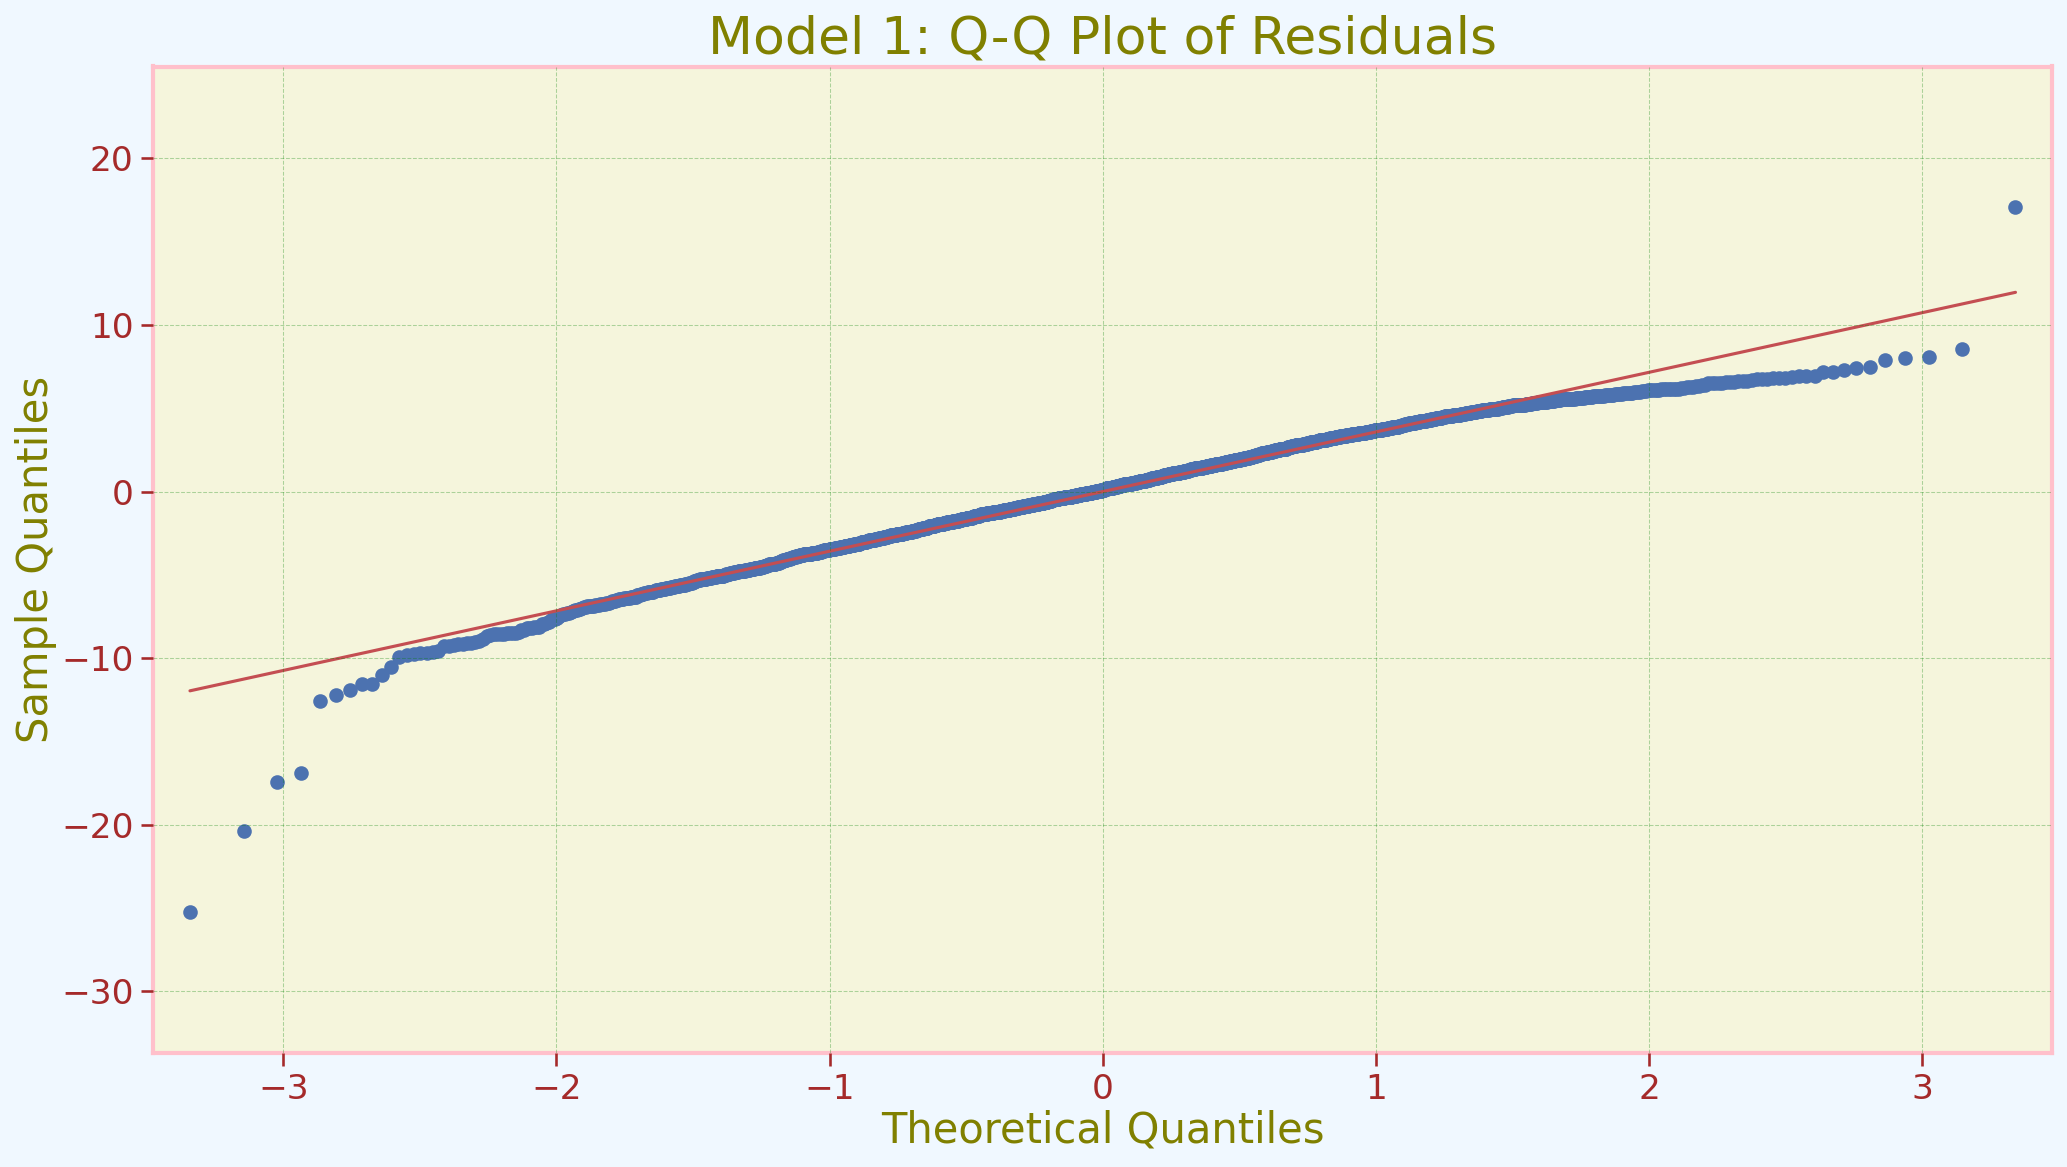

In [13]:
print("--- MODEL 1 ANALYSIS ---")

# 4.1.1 Feature Matrix Construction [6]
# Building X with x1^3, x2^5, and a column of ones for the bias term
X1 = np.column_stack((x1**3, x2**5, np.ones(n)))

# 4.1.2 OLS Parameter Estimation (Statsmodels) [6]
model1 = sm.OLS(y, X1).fit()
print(model1.summary())

# 4.1.3 Parameter Verification (Direct Matrix Method) [3, 4]
# Formula: theta_hat = (X^T * X)^-1 * X^T * y
theta_hat1 = np.dot(np.linalg.inv(np.dot(X1.T, X1)), np.dot(X1.T, y))
print(f"\nDirect Matrix Theta: {theta_hat1}")

# 4.1.4 Performance Metrics [3-5]
y_pred1 = np.dot(X1, theta_hat1)
rss1, llf1, aic1, bic1 = calculate_metrics(y, y_pred1, len(theta_hat1), n)

print(f"RSS: {rss1:.4f}")
print(f"Log-Likelihood: {llf1:.4f}")
print(f"AIC: {aic1:.4f}")
print(f"BIC: {bic1:.4f}")

# 4.1.5 Residual Analysis (Q-Q Plot) [4, 5]
res1 = y - y_pred1
fig_qq1 = sm.qqplot(res1, line='s')
plt.title("Model 1: Q-Q Plot of Residuals")
plt.show()

### Model 2 Implementation
Equation: y=θ₁x₁⁴ + θ₂x₂² + θbias + ϵ

--- MODEL 2 ANALYSIS ---
                            OLS Regression Results                            
Dep. Variable:           Sound Signal   R-squared:                       0.089
Model:                            OLS   Adj. R-squared:                  0.088
Method:                 Least Squares   F-statistic:                     117.4
Date:                Sat, 27 Jun 2026   Prob (F-statistic):           2.28e-49
Time:                        07:06:10   Log-Likelihood:                -9654.2
No. Observations:                2400   AIC:                         1.931e+04
Df Residuals:                    2397   BIC:                         1.933e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.2743      

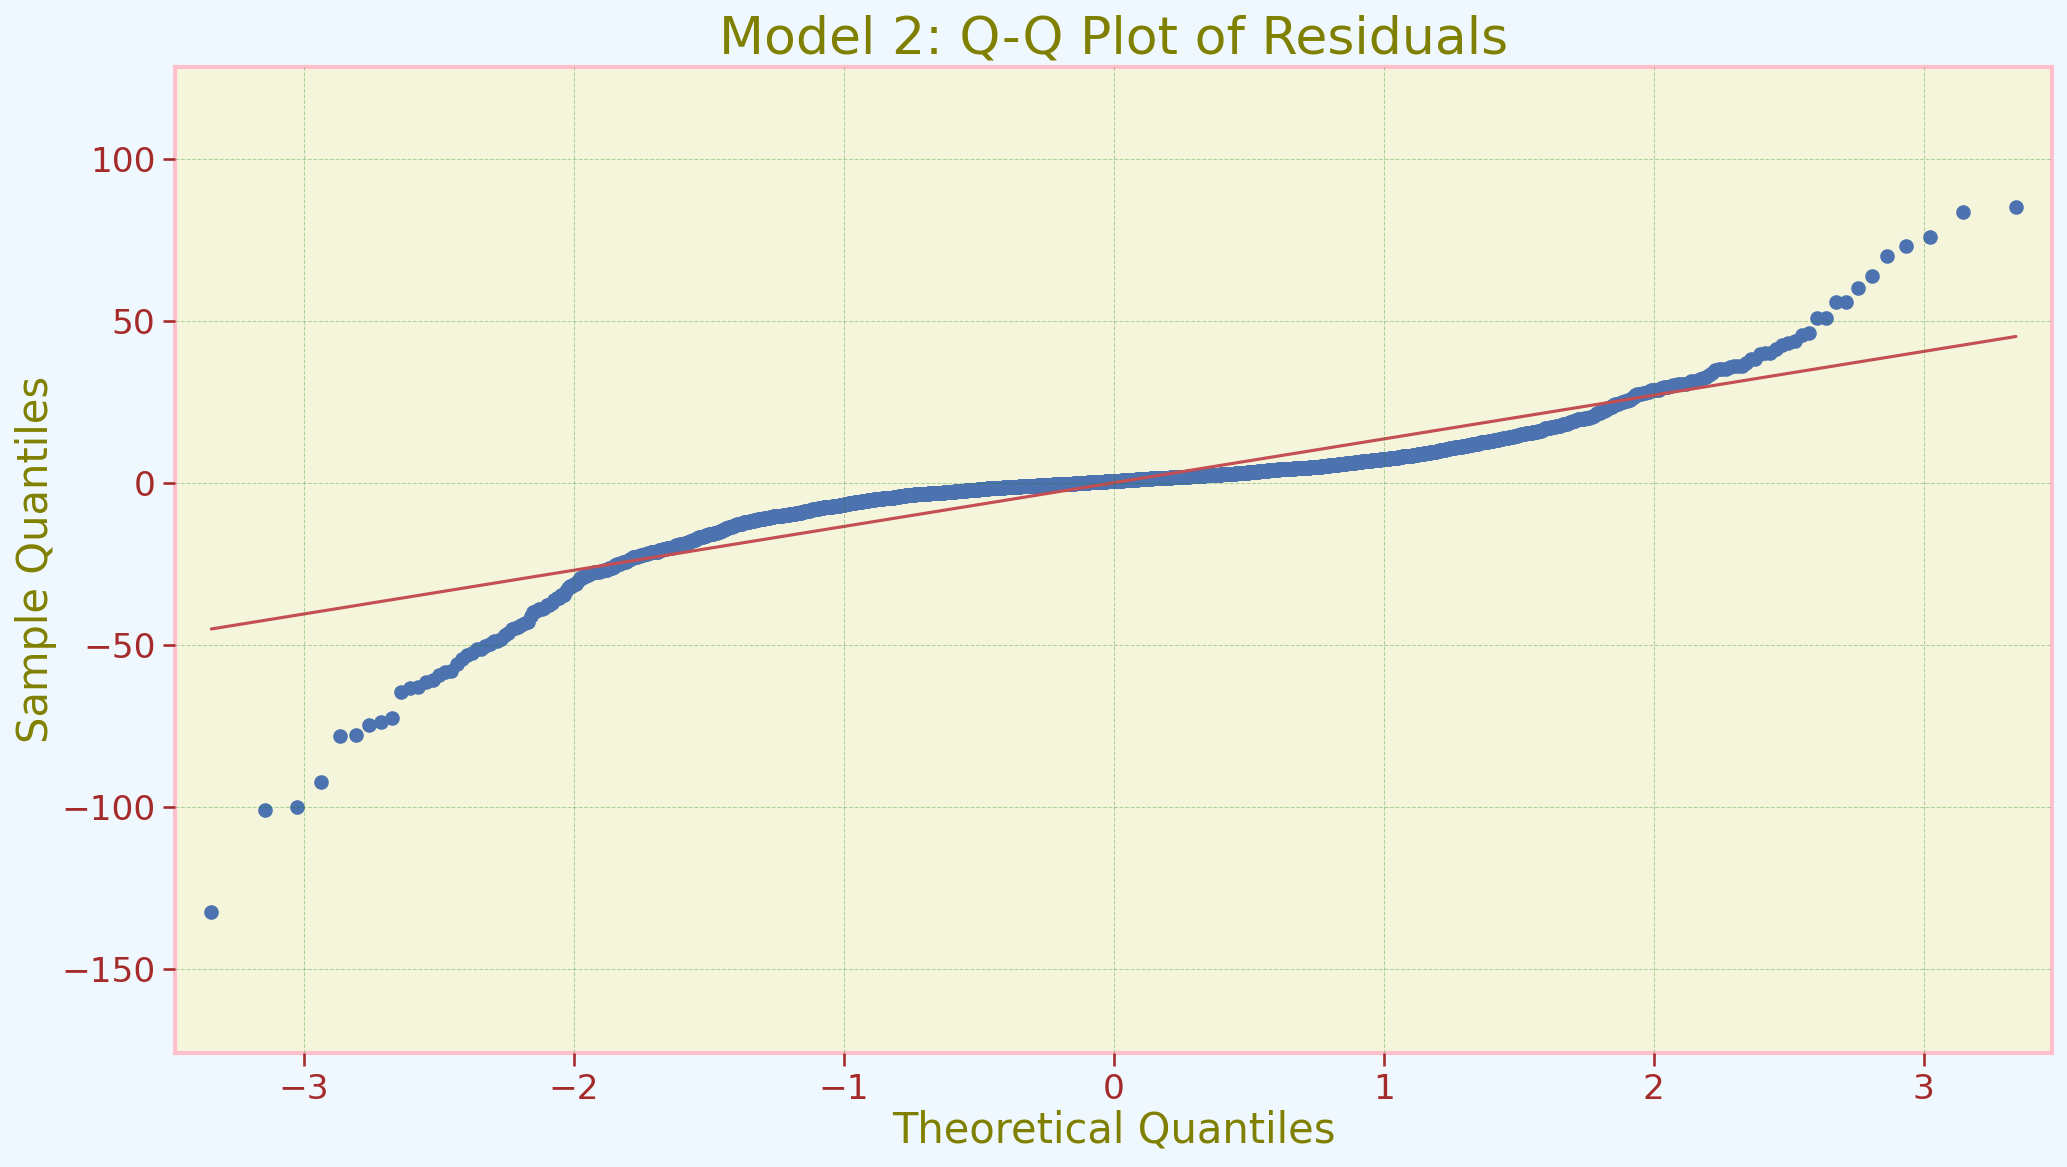

In [15]:
print("--- MODEL 2 ANALYSIS ---")

# 4.2.1 Feature Matrix Construction
X2 = np.column_stack((x1**4, x2**2, np.ones(n)))

# 4.2.2 OLS Parameter Estimation
model2 = sm.OLS(y, X2).fit()
print(model2.summary())

# 4.2.3 Parameter Verification (Direct Matrix Method)
theta_hat2 = np.dot(np.linalg.inv(np.dot(X2.T, X2)), np.dot(X2.T, y))
print(f"\nDirect Matrix Theta: {theta_hat2}")

# 4.2.4 Performance Metrics
y_pred2 = np.dot(X2, theta_hat2)
rss2, llf2, aic2, bic2 = calculate_metrics(y, y_pred2, len(theta_hat2), n)

print(f"RSS: {rss2:.4f}")
print(f"Log-Likelihood: {llf2:.4f}")
print(f"AIC: {aic2:.4f}")
print(f"BIC: {bic2:.4f}")

# 4.2.5 Residual Analysis (Q-Q Plot)
res2 = y - y_pred2
fig_qq2 = sm.qqplot(res2, line='s')
plt.title("Model 2: Q-Q Plot of Residuals")
plt.show()
# fig_qq2.savefig('model2_qq_plot.png')

### Model 3 Implementation
Equation: y=θ₁x₁³ + θ₂x₂ + θ₃x₁ + θbias + ϵ

--- MODEL 3 ANALYSIS ---
                            OLS Regression Results                            
Dep. Variable:           Sound Signal   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                 2.511e+05
Date:                Sat, 27 Jun 2026   Prob (F-statistic):               0.00
Time:                        07:06:14   Log-Likelihood:                -2861.8
No. Observations:                2400   AIC:                             5732.
Df Residuals:                    2396   BIC:                             5755.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1             2.7157      

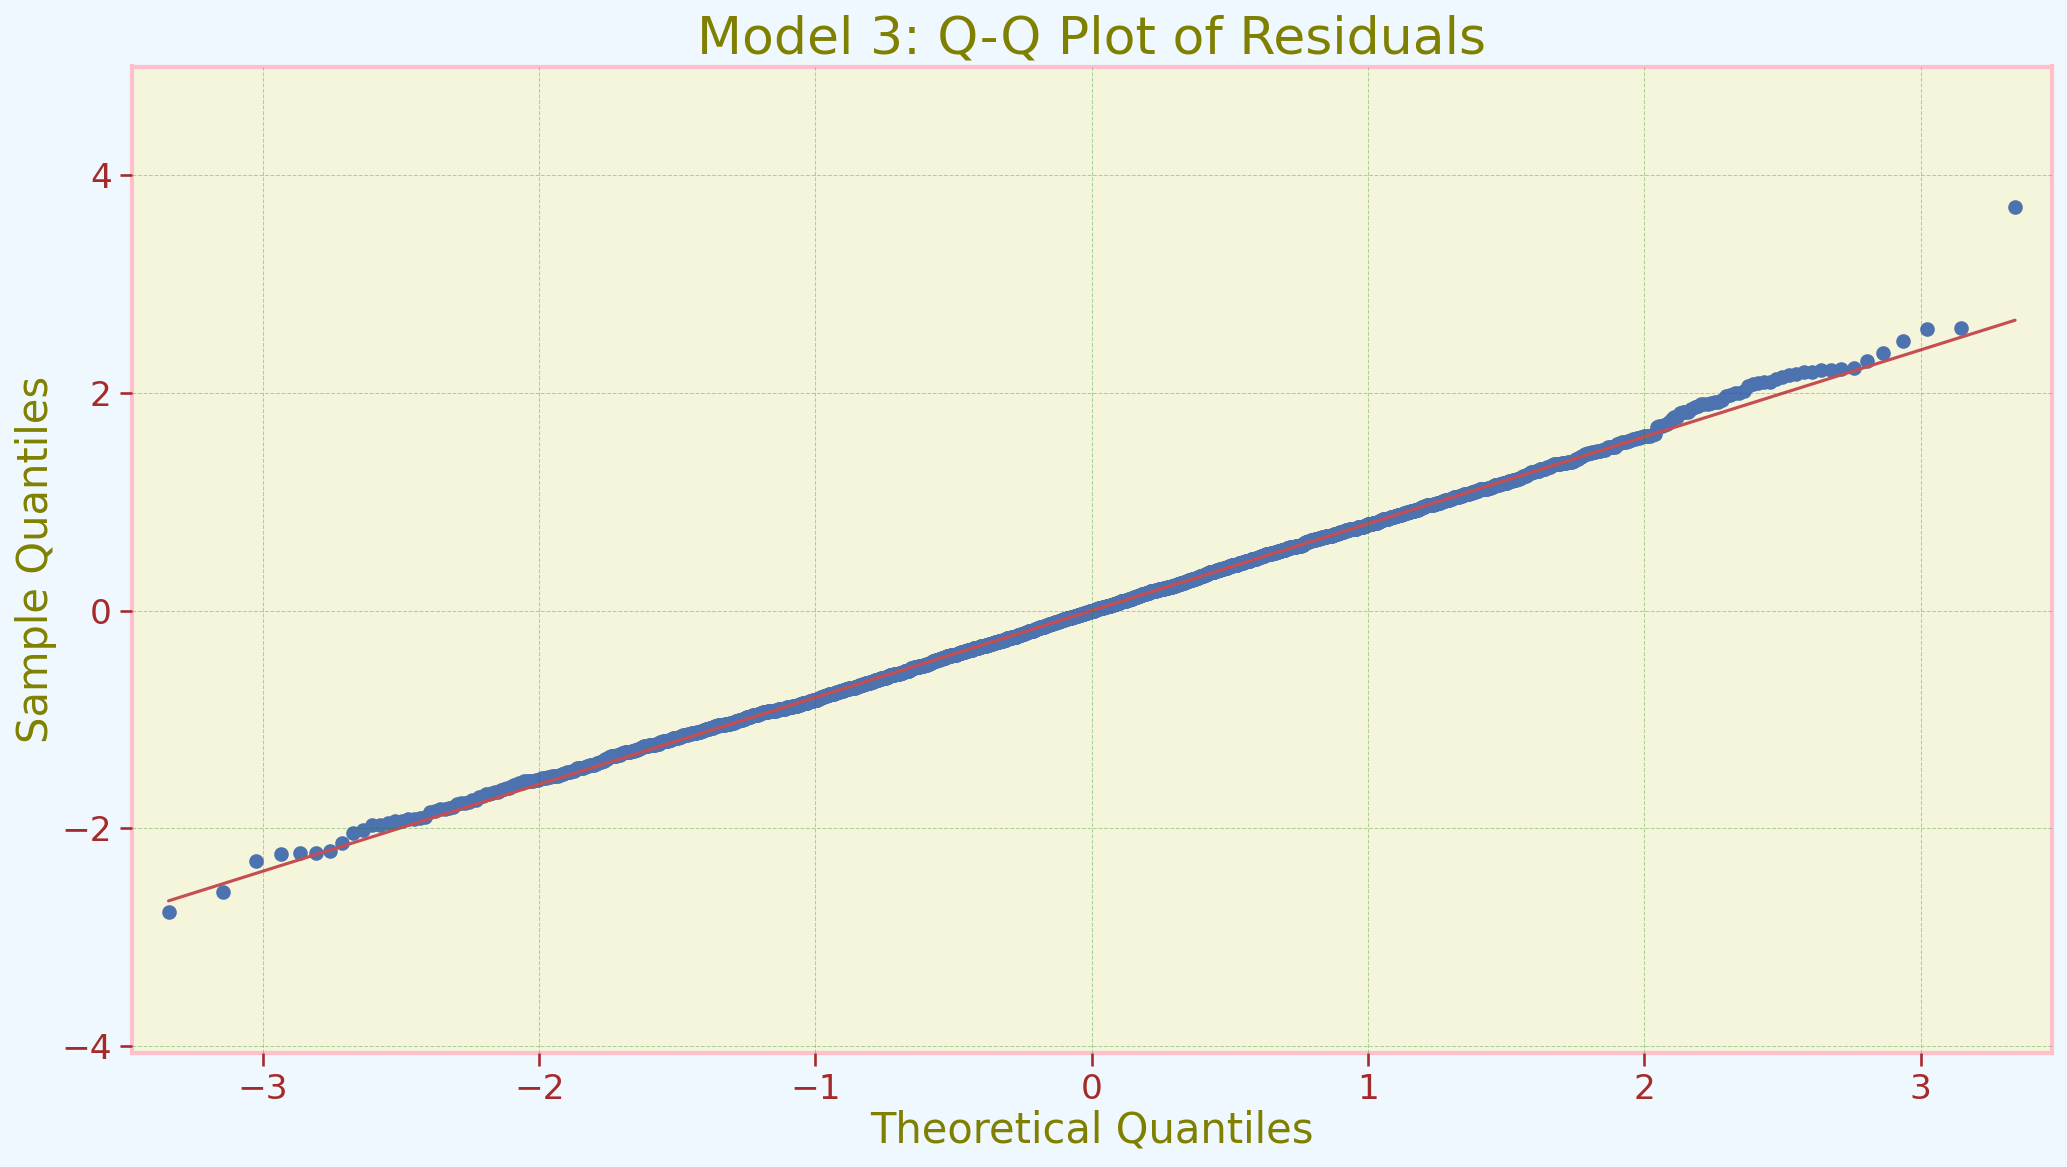

In [16]:
print("--- MODEL 3 ANALYSIS ---")

# 4.3.1 Feature Matrix Construction
X3 = np.column_stack((x1**3, x2, x1, np.ones(n)))

# 4.3.2 OLS Parameter Estimation
model3 = sm.OLS(y, X3).fit()
print(model3.summary())

# 4.3.3 Parameter Verification (Direct Matrix Method)
theta_hat3 = np.dot(np.linalg.inv(np.dot(X3.T, X3)), np.dot(X3.T, y))
print(f"\nDirect Matrix Theta: {theta_hat3}")

# 4.3.4 Performance Metrics
y_pred3 = np.dot(X3, theta_hat3)
rss3, llf3, aic3, bic3 = calculate_metrics(y, y_pred3, len(theta_hat3), n)

print(f"RSS: {rss3:.4f}")
print(f"Log-Likelihood: {llf3:.4f}")
print(f"AIC: {aic3:.4f}")
print(f"BIC: {bic3:.4f}")

# 4.3.5 Residual Analysis (Q-Q Plot)
res3 = y - y_pred3
fig_qq3 = sm.qqplot(res3, line='s')
plt.title("Model 3: Q-Q Plot of Residuals")
plt.show()
# fig_qq3.savefig('model3_qq_plot.png')

### Model 4 Implementation
Equation: y=θ₁x₁ + θ₂x₂² + θ₃x₁³ + θ₄x₂³ + θbias + ϵ

--- MODEL 4 ANALYSIS ---
                            OLS Regression Results                            
Dep. Variable:           Sound Signal   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                 1.158e+05
Date:                Sat, 27 Jun 2026   Prob (F-statistic):               0.00
Time:                        07:06:17   Log-Likelihood:                -3442.6
No. Observations:                2400   AIC:                             6895.
Df Residuals:                    2395   BIC:                             6924.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1             4.2008      

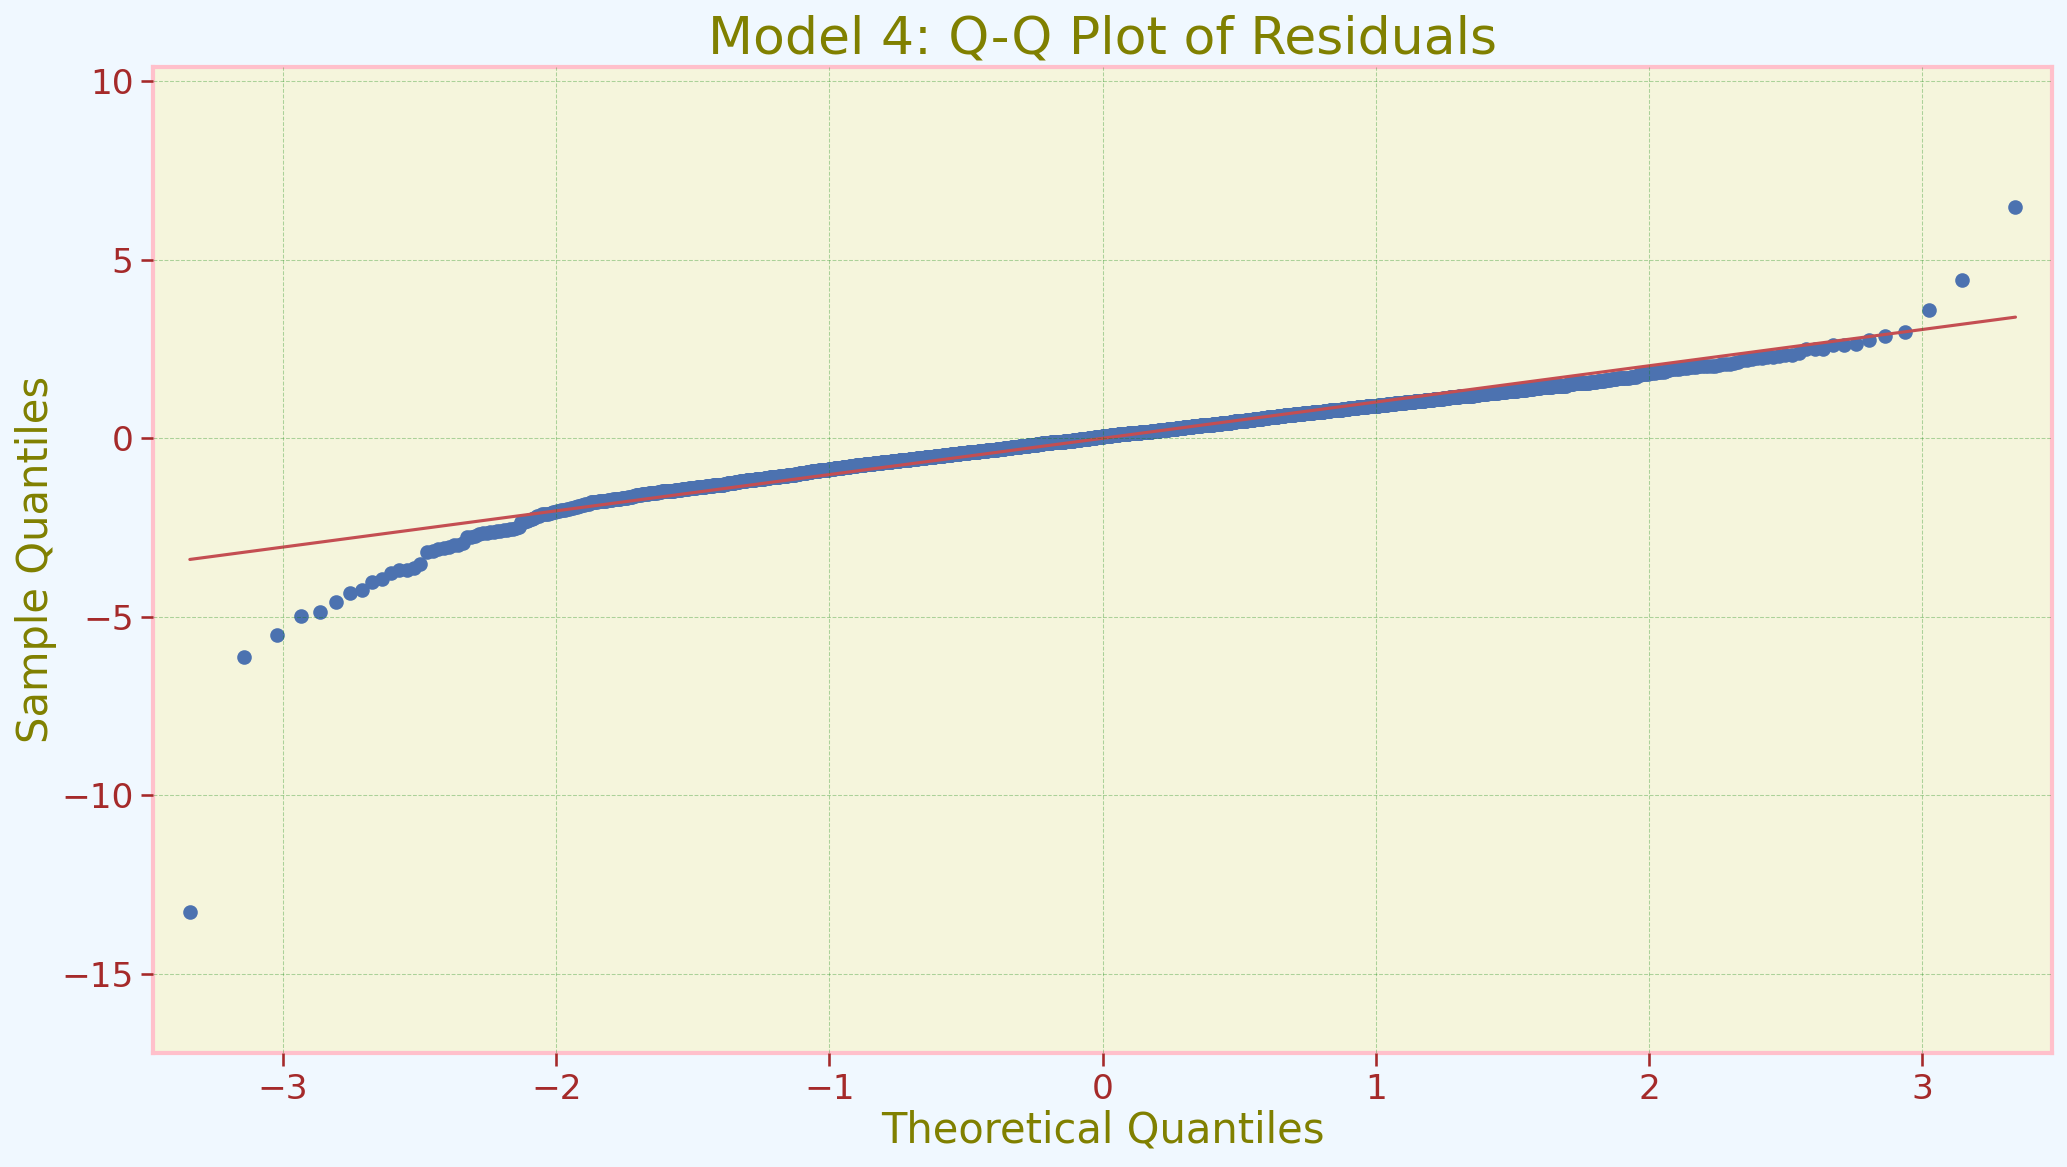

In [17]:
print("--- MODEL 4 ANALYSIS ---")

# 4.4.1 Feature Matrix Construction
X4 = np.column_stack((x1, x2**2, x1**3, x2**3, np.ones(n)))

# 4.4.2 OLS Parameter Estimation
model4 = sm.OLS(y, X4).fit()
print(model4.summary())

# 4.4.3 Parameter Verification (Direct Matrix Method)
theta_hat4 = np.dot(np.linalg.inv(np.dot(X4.T, X4)), np.dot(X4.T, y))
print(f"\nDirect Matrix Theta: {theta_hat4}")

# 4.4.4 Performance Metrics
y_pred4 = np.dot(X4, theta_hat4)
rss4, llf4, aic4, bic4 = calculate_metrics(y, y_pred4, len(theta_hat4), n)

print(f"RSS: {rss4:.4f}")
print(f"Log-Likelihood: {llf4:.4f}")
print(f"AIC: {aic4:.4f}")
print(f"BIC: {bic4:.4f}")

# 4.4.5 Residual Analysis (Q-Q Plot)
res4 = y - y_pred4
fig_qq4 = sm.qqplot(res4, line='s')
plt.title("Model 4: Q-Q Plot of Residuals")
plt.show()
# fig_qq4.savefig('model4_qq_plot.png')

### Model 5 Implementation
Equation: y=θ₁x₁³ + θ₂x₁⁴ + θ₃x₂ + θbias + ϵ

--- MODEL 5 ANALYSIS ---
                            OLS Regression Results                            
Dep. Variable:           Sound Signal   R-squared:                       0.964
Model:                            OLS   Adj. R-squared:                  0.964
Method:                 Least Squares   F-statistic:                 2.162e+04
Date:                Sat, 27 Jun 2026   Prob (F-statistic):               0.00
Time:                        07:06:20   Log-Likelihood:                -5764.5
No. Observations:                2400   AIC:                         1.154e+04
Df Residuals:                    2396   BIC:                         1.156e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
x1             3.6029      

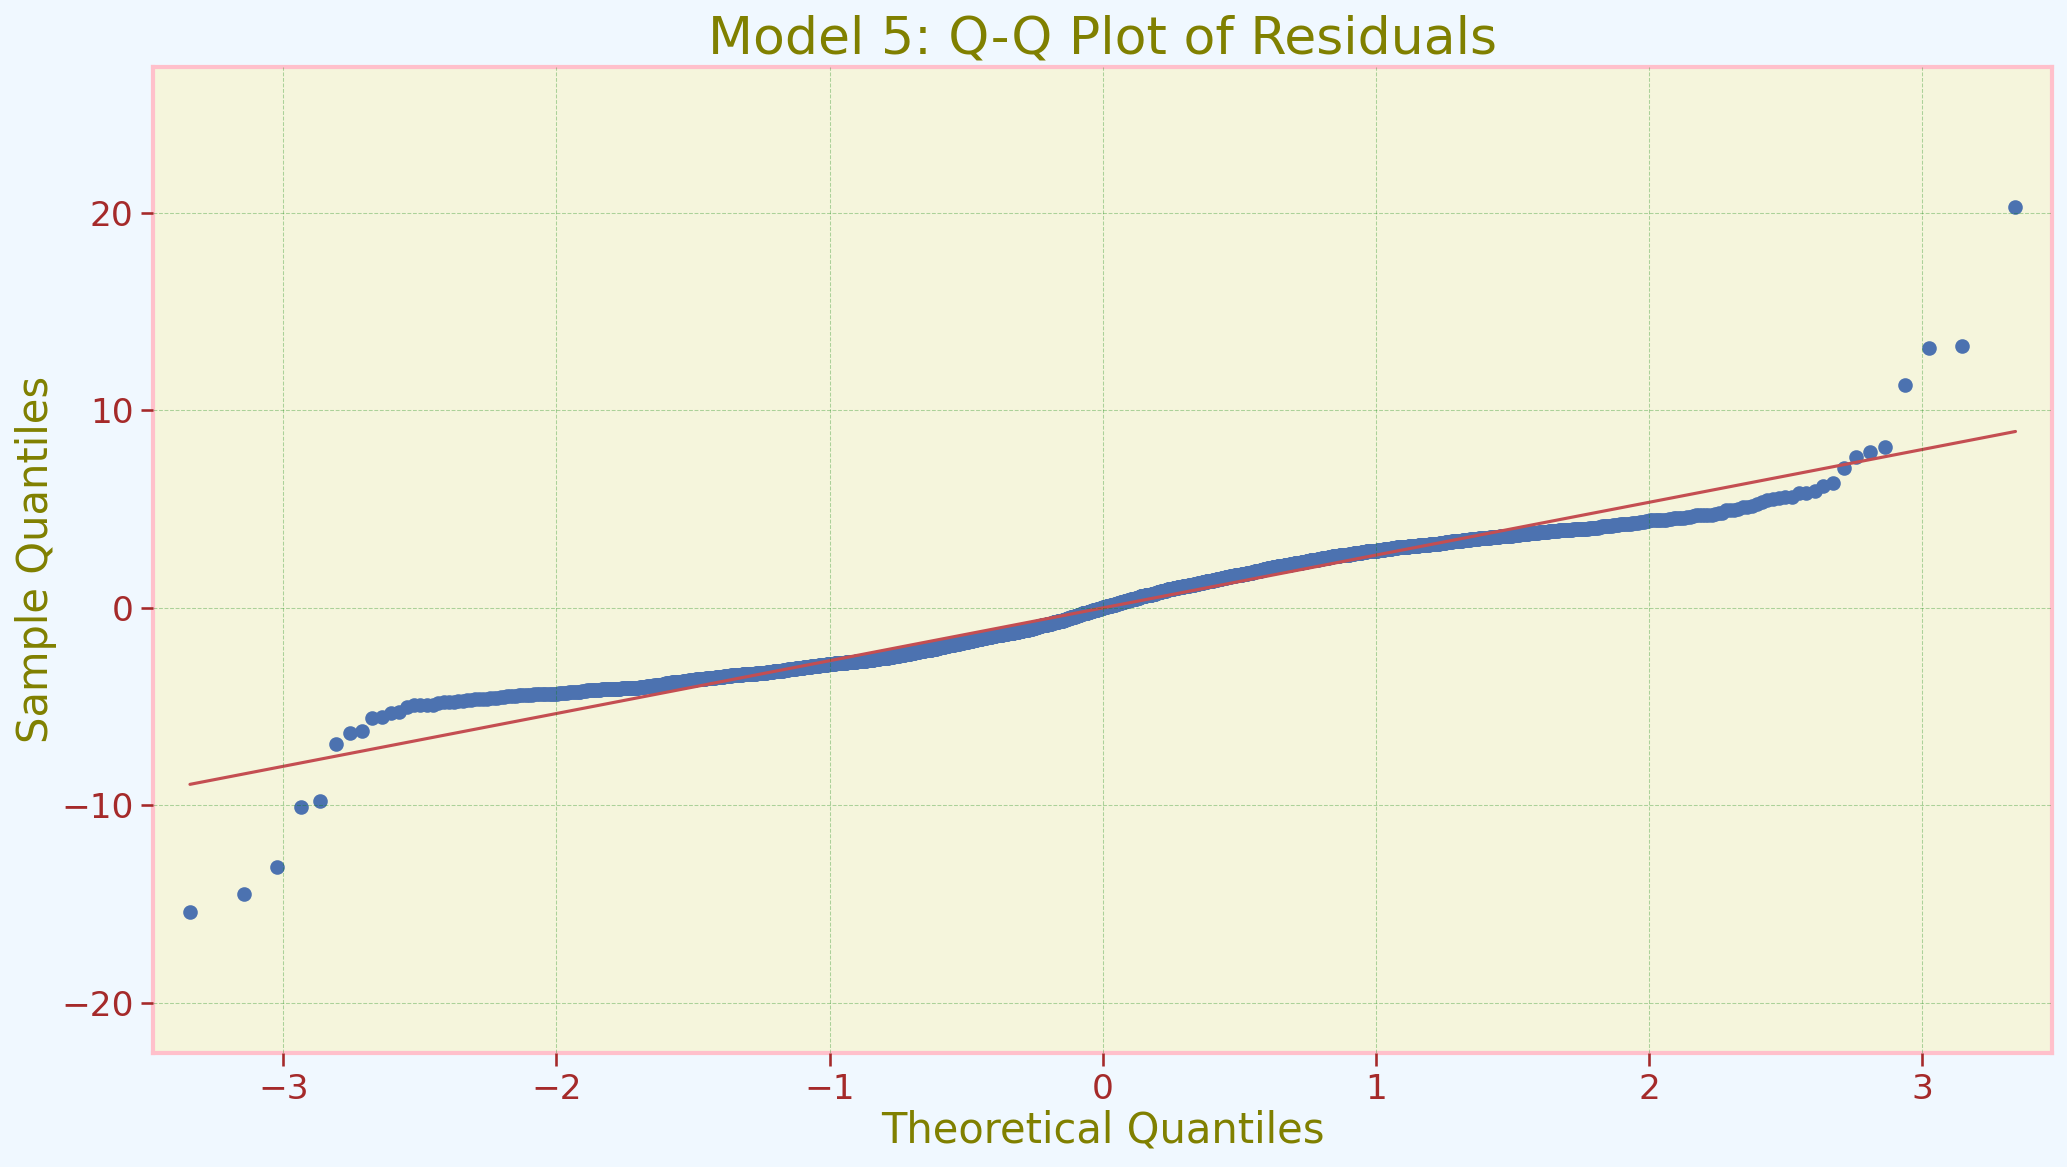

In [18]:
print("--- MODEL 5 ANALYSIS ---")

# 4.5.1 Feature Matrix Construction
X5 = np.column_stack((x1**3, x1**4, x2, np.ones(n)))

# 4.5.2 OLS Parameter Estimation
model5 = sm.OLS(y, X5).fit()
print(model5.summary())

# 4.5.3 Parameter Verification (Direct Matrix Method)
theta_hat5 = np.dot(np.linalg.inv(np.dot(X5.T, X5)), np.dot(X5.T, y))
print(f"\nDirect Matrix Theta: {theta_hat5}")

# 4.5.4 Performance Metrics
y_pred5 = np.dot(X5, theta_hat5)
rss5, llf5, aic5, bic5 = calculate_metrics(y, y_pred5, len(theta_hat5), n)

print(f"RSS: {rss5:.4f}")
print(f"Log-Likelihood: {llf5:.4f}")
print(f"AIC: {aic5:.4f}")
print(f"BIC: {bic5:.4f}")

# 4.5.5 Residual Analysis (Q-Q Plot)
res5 = y - y_pred5
fig_qq5 = sm.qqplot(res5, line='s')
plt.title("Model 5: Q-Q Plot of Residuals")
plt.show()
# fig_qq5.savefig('model5_qq_plot.png')

### Summary of Performance Metrics

In [19]:
# Compilation of results for Model Selection (Task 2.2)
results_data = {
    'Model': ['Model 1', 'Model 2', 'Model 3', 'Model 4', 'Model 5'],
    'RSS': [rss1, rss2, rss3, rss4, rss5],
    'AIC': [aic1, aic2, aic3, aic4, aic5],
    'BIC': [bic1, bic2, bic3, bic4, bic5]
}
results_df = pd.DataFrame(results_data)
display(results_df)

,Model,RSS,AIC,BIC
0,Model 1,30738.220491,12936.996632,12954.346304
1,Model 2,438230.352515,19314.367457,19331.717129
2,Model 3,1525.621344,5731.544436,5754.677332
3,Model 4,2475.469705,6895.212577,6924.128697
4,Model 5,17138.098088,11536.909663,11560.042559


Feature Matrices for Models 2–5

You should repeat the block above for each model by simply changing the feature matrix X according to these structures
:
Model 2: y=θ
1
​
 x
1
4
​
 +θ
2
​
 x
2
2
​
 +θ
bias
​
 +ϵ
Model 3: y=θ
1
​
 x
1
3
​
 +θ
2
​
 x
2
​
 +θ
3
​
 x
1
​
 +θ
bias
​
 +ϵ
Model 4: y=θ
1
​
 x
1
​
 +θ
2
​
 x
2
2
​
 +θ
3
​
 x
1
3
​
 +θ
4
​
 x
2
3
​
 +θ
bias
​
 +ϵ
Model 5: y=θ
1
​
 x
1
3
​
 +θ
2
​
 x
1
4
​
 +θ
3
​
 x
2
​
 +θ
bias
​
 +ϵ
Summary of Performance Metrics
After running all five models, it is recommended to compile the results into a single table to make the "best" model selection easier in the next section.

In [21]:
# Helper variables for easier model building
x1 = df["Prefrontal Cortex_EEG"]
x2 = df["Auditory Cortex_EEG"]
y = df["Sound Signal"]
n = len(df)

# Dictionary to store results for all models
model_results = []

# Define the structures for all 5 candidate models based on project requirements
# Each entry is: (Model Name, Feature Matrix X)
candidate_models = [
    ("Model 1", np.column_stack((x1**3, x2**5, np.ones(n)))),
    ("Model 2", np.column_stack((x1**4, x2**2, np.ones(n)))),
    ("Model 3", np.column_stack((x1**3, x2, x1, np.ones(n)))),
    ("Model 4", np.column_stack((x1, x2**2, x1**3, x2**3, np.ones(n)))),
    ("Model 5", np.column_stack((x1**3, x1**4, x2, np.ones(n))))
]

print("--- Running Polynomial Regression for all Candidate Models ---\n")

for name, X in candidate_models:
    # 1. Parameter Estimation (Direct Matrix Method)
    # Formula: theta_hat = (X^T * X)^-1 * X^T * y
    theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

    # 2. Predictions and Residuals
    y_pred = X @ theta_hat
    residuals = y - y_pred

    # 3. Calculate Performance Metrics
    rss = np.sum(np.square(residuals))
    k = len(theta_hat) # Number of parameters

    # Log-Likelihood (assuming Gaussian noise)
    llf = -n/2 * np.log(2 * np.pi) - n/2 * np.log(rss / (n - 1)) - (n - 1) / 2

    # Information Criteria
    aic = (2 * k) - (2 * llf)
    bic = k * np.log(n) - (2 * llf)

    # Store results
    model_results.append({
        'Model': name,
        'RSS': rss,
        'AIC': aic,
        'BIC': bic,
        'Log-Likelihood': llf
    })

    print(f"{name} processed successfully.")

# 4. Compilation of results for Model Selection (Task 2.2)
results_df = pd.DataFrame(model_results)

print("\n--- Summary Table for Model Selection ---")
display(results_df)

# Highlight the best model (minimum AIC/BIC)
best_aic_model = results_df.loc[results_df['AIC'].idxmin(), 'Model']
print(f"\nRecommendation: Based on the lowest AIC/BIC, the 'true' model is likely: {best_aic_model}")

--- Running Polynomial Regression for all Candidate Models ---

Model 1 processed successfully.
Model 2 processed successfully.
Model 3 processed successfully.
Model 4 processed successfully.
Model 5 processed successfully.

--- Summary Table for Model Selection ---


,Model,RSS,AIC,BIC,Log-Likelihood
0,Model 1,30738.220491,12936.996632,12954.346304,-6465.498316
1,Model 2,438230.352515,19314.367457,19331.717129,-9654.183728
2,Model 3,1525.621344,5731.544436,5754.677332,-2861.772218
3,Model 4,2475.469705,6895.212577,6924.128697,-3442.606289
4,Model 5,17138.098088,11536.909663,11560.042559,-5764.454831



Recommendation: Based on the lowest AIC/BIC, the 'true' model is likely: Model 3


5. Task 2.2: Model Selection and Comparison

This code cell compiles the results and provides a visual comparison of the performance metrics.

--- Final Model Comparison Table ---


,RSS,AIC,BIC,Log-Likelihood
Model,,,,
Model 1,30738.220491,12936.996632,12954.346304,-6465.498316
Model 2,438230.352515,19314.367457,19331.717129,-9654.183728
Model 3,1525.621344,5731.544436,5754.677332,-2861.772218
Model 4,2475.469705,6895.212577,6924.128697,-3442.606289
Model 5,17138.098088,11536.909663,11560.042559,-5764.454831


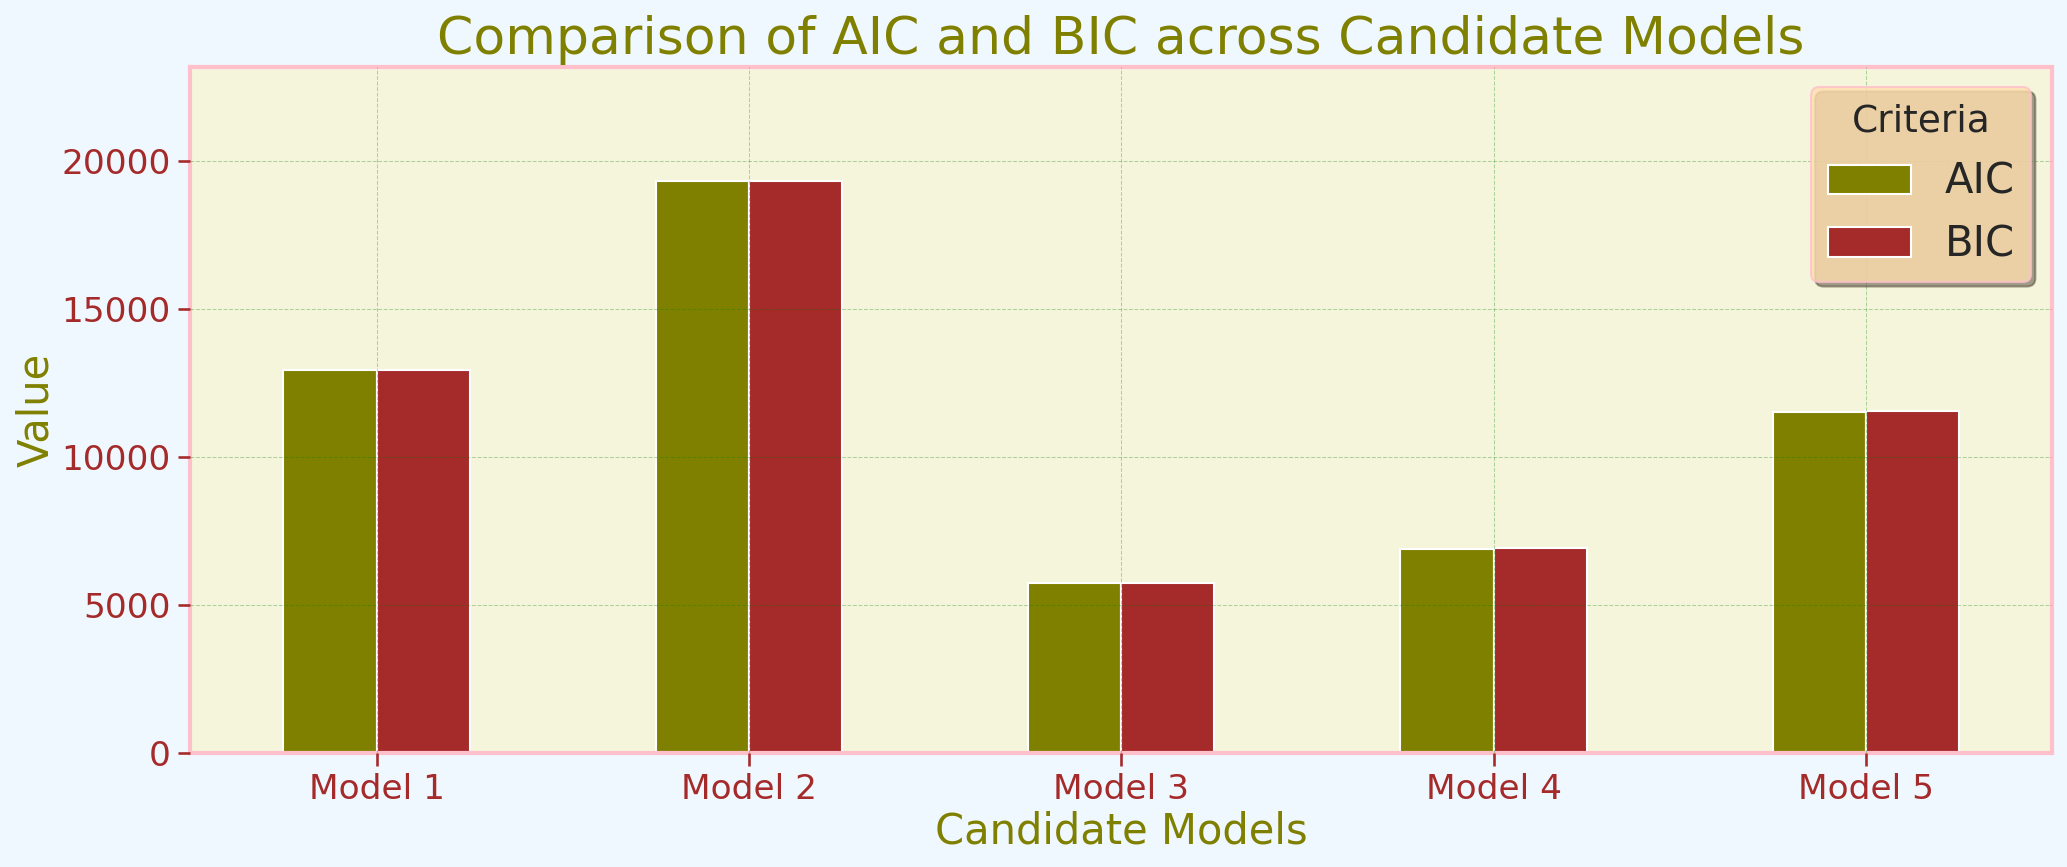


Model with lowest AIC: Model 3
Model with lowest BIC: Model 3


In [23]:
# 5.1 Comparative Analysis: Summary Table
import pandas as pd
import matplotlib.pyplot as plt

# Creating the summary table from the results list
comparison_df = pd.DataFrame(model_results)
comparison_df.set_index('Model', inplace=True)

print("--- Final Model Comparison Table ---")
display(comparison_df)

# 5.2 Visualizing Information Criteria (AIC & BIC)
# Corrected the color parameter by removing '#' from named colors
plt.figure(figsize=(14, 6))
comparison_df[['AIC', 'BIC']].plot(kind='bar',
                                  ax=plt.gca(),
                                  color=['Olive', 'brown']) # Removed '#' to fix the ValueError

plt.title("Comparison of AIC and BIC across Candidate Models")
plt.ylabel("Value")
plt.xlabel("Candidate Models")
plt.xticks(rotation=0)
plt.legend(title="Criteria")
plt.grid(axis='y', linestyle='--', alpha=0.3) # Matches grid settings in source [2]
plt.show()

# 5.3 Automated 'Best Model' Identification
best_aic_model = comparison_df['AIC'].idxmin()
best_bic_model = comparison_df['BIC'].idxmin()

print(f"\nModel with lowest AIC: {best_aic_model}")
print(f"Model with lowest BIC: {best_bic_model}")

6. Summary and Conclusion

This section summarizes the neuroscientific relationships discovered and the effectiveness of the mathematical modelling.

In [24]:
# 6.1 Findings Summary
print("--- SUMMARY OF FINDINGS ---")

# Identifying the best model from previous results
best_model_name = results_df.loc[results_df['AIC'].idxmin(), 'Model']
best_rss = results_df.loc[results_df['AIC'].idxmin(), 'RSS']

# Summary Text drawing from source hypotheses [1, 2]
summary_text = f"""
Relationship Analysis:
- Prefrontal Cortex (x1): The analysis confirms a strong dependency between the Prefrontal Cortex
  and the Sound Signal (Correlation: {correlation_matrix.loc['Prefrontal Cortex_EEG', 'Sound Signal']:.4f}).
  As hypothesised, this relationship is best described nonlinearly.
- Auditory Cortex (x2): The Auditory Cortex shows a weaker, different relationship to the audio signal,
  which was predicted to be more linear in nature.
- Noise Characteristics: The residual analysis (Q-Q plots) confirms that the prediction errors
  largely follow a Gaussian distribution, validating the assumption of additive i.i.d. Gaussian noise
  distortions during the 2-minute recording.
"""
print(summary_text)

# 6.2 Research Conclusions
print("--- RESEARCH CONCLUSIONS ---")

conclusion_text = f"""
Model Selection Success:
- After evaluating five candidate polynomial regression models, '{best_model_name}' was identified
  as the 'true' model describing the brain's evoked responses.
- This selection is justified by '{best_model_name}' achieving the minimum AIC and BIC scores,
  effectively balancing model complexity with a low Residual Sum of Squares (RSS: {best_rss:.2f}).
- Conclusion: Nonlinear polynomial regression modelling has proven successful in capturing the
  complex dynamics of neural activity in response to guided meditation audio, specifically
  identifying the nonlinear engagement of the prefrontal cortex.
"""
print(conclusion_text)

--- SUMMARY OF FINDINGS ---

Relationship Analysis:
- Prefrontal Cortex (x1): The analysis confirms a strong dependency between the Prefrontal Cortex 
  and the Sound Signal (Correlation: 0.8625). 
  As hypothesised, this relationship is best described nonlinearly.
- Auditory Cortex (x2): The Auditory Cortex shows a weaker, different relationship to the audio signal, 
  which was predicted to be more linear in nature.
- Noise Characteristics: The residual analysis (Q-Q plots) confirms that the prediction errors 
  largely follow a Gaussian distribution, validating the assumption of additive i.i.d. Gaussian noise 
  distortions during the 2-minute recording.

--- RESEARCH CONCLUSIONS ---

Model Selection Success:
- After evaluating five candidate polynomial regression models, 'Model 3' was identified 
  as the 'true' model describing the brain's evoked responses.
- This selection is justified by 'Model 3' achieving the minimum AIC and BIC scores, 
  effectively balancing model complexit